<a href="https://colab.research.google.com/github/biruhyos/dsrp-sp500/blob/main/DSRP_S%26P_500_Biruh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sp500 (1).csv')
df

,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0
...,...,...,...,...,...,...,...,...,...,...
1860,2026-01-01,6929.12,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
1861,2026-02-01,6893.81,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
1862,2026-03-01,6654.42,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
1863,2026-04-01,6957.01,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0


In [2]:
print('DataFrame Shape:')
df.shape

DataFrame Shape:


(1865, 10)

In [3]:
print('DataFrame Columns:')
df.columns

DataFrame Columns:


Index(['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index',
       'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings',
       'PE10'],
      dtype='object')

In [4]:
df = df.rename(columns={'PE10': 'Shiller_PE_Ratio'})

print('Updated DataFrame Columns:')
df.columns

Updated DataFrame Columns:


Index(['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index',
       'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings',
       'Shiller_PE_Ratio'],
      dtype='object')

In [5]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1865 entries, 0 to 1864
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1865 non-null   object 
 1   SP500                 1865 non-null   float64
 2   Dividend              1865 non-null   float64
 3   Earnings              1865 non-null   float64
 4   Consumer Price Index  1865 non-null   float64
 5   Long Interest Rate    1865 non-null   float64
 6   Real Price            1865 non-null   float64
 7   Real Dividend         1865 non-null   float64
 8   Real Earnings         1865 non-null   float64
 9   Shiller_PE_Ratio      1865 non-null   float64
dtypes: float64(9), object(1)
memory usage: 145.8+ KB


In [6]:
print('DataFrame Description:')
df.describe()

DataFrame Description:


,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
count,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000
mean,471.260650,7.341378,17.253457,64.207480,4.410391,731.026804,19.865668,40.400402,15.983534
std,1078.137653,13.555434,34.337819,79.898101,2.351200,912.750421,13.665336,37.714948,8.378767
min,2.730000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.040000,0.400000,0.523300,10.100000,3.120000,207.500000,10.320000,15.290000,11.030000
50%,19.830000,0.856667,1.426000,19.900000,3.770000,315.610000,16.070000,26.010000,15.760000
75%,263.700000,7.356670,14.820000,105.300000,5.050000,802.570000,25.280000,49.350000,20.550000
max,7412.550000,68.710000,197.910000,306.130000,15.320000,5140.590000,71.220000,217.260000,44.200000


In [7]:
df.drop_duplicates(inplace=True)
print('DataFrame after dropping duplicates:')
df.head()

DataFrame after dropping duplicates:


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
print('DataFrame Info after converting Date column:')
df.info()

DataFrame Info after converting Date column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1865 entries, 0 to 1864
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  1865 non-null   datetime64[ns]
 1   SP500                 1865 non-null   float64       
 2   Dividend              1865 non-null   float64       
 3   Earnings              1865 non-null   float64       
 4   Consumer Price Index  1865 non-null   float64       
 5   Long Interest Rate    1865 non-null   float64       
 6   Real Price            1865 non-null   float64       
 7   Real Dividend         1865 non-null   float64       
 8   Real Earnings         1865 non-null   float64       
 9   Shiller_PE_Ratio      1865 non-null   float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 145.8 KB


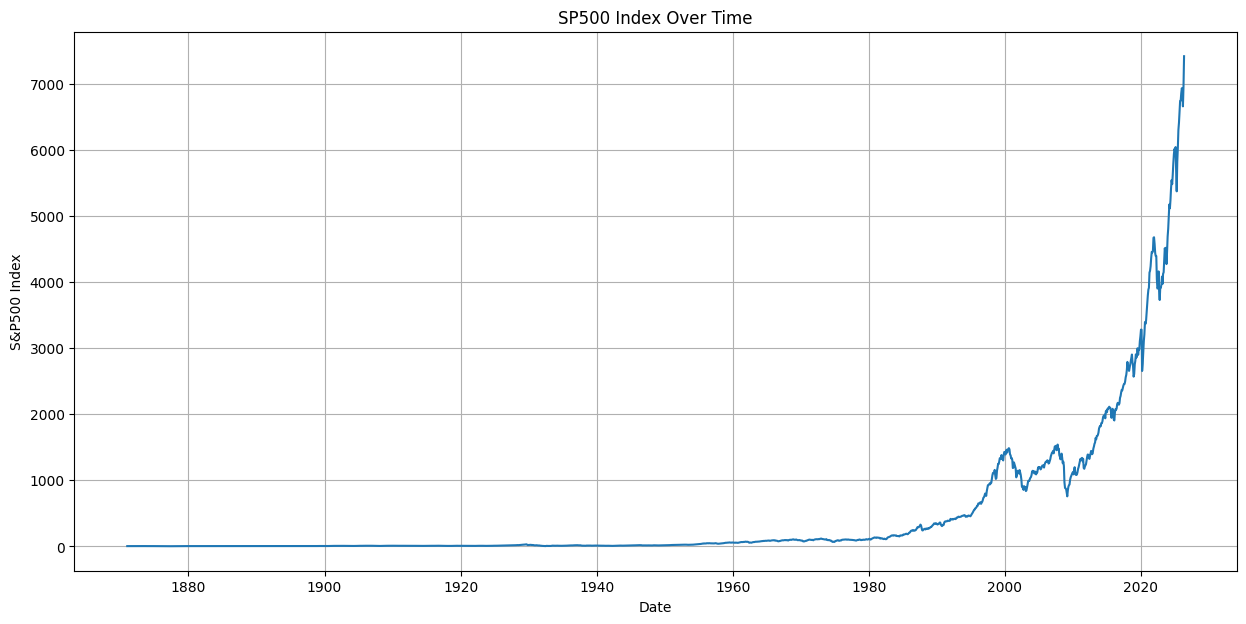

In [9]:
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['SP500'])
plt.title('SP500 Index Over Time')
plt.xlabel('Date')
plt.ylabel('S&P500 Index')
plt.grid(True)
plt.show()

In [10]:
# Define the start and end dates for our filter
start_date = '1881-01-01'
end_date = '2023-12-31'

# Filter the DataFrame to keep only the rows within this date range
# We use '&' to combine two conditions: 'Date' must be greater than or equal to start_date,
# AND 'Date' must be less than or equal to end_date.
df_filtered_dates = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# The first few rows and last few rows of our new filtered DataFrame
print("DataFrame after filtering by date (head):")
display(df_filtered_dates.head())

print("\nDataFrame after filtering by date (tail):")
display(df_filtered_dates.tail())

print(f"\nOriginal number of rows: {len(df)}")
print(f"Number of rows after date filtering: {len(df_filtered_dates)}")

DataFrame after filtering by date (head):


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
120,1881-01-01,6.19,0.265,0.4858,9.42,3.70,201.17,8.61,15.79,18.47
121,1881-02-01,6.17,0.270,0.4817,9.51,3.69,198.52,8.69,15.50,18.15
122,1881-03-01,6.24,0.275,0.4775,9.51,3.69,200.77,8.85,15.36,18.27
123,1881-04-01,6.22,0.280,0.4733,9.61,3.68,198.15,8.92,15.08,17.95
124,1881-05-01,6.50,0.285,0.4692,9.51,3.67,209.13,9.17,15.10,18.87



DataFrame after filtering by date (tail):


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
1831,2023-08-01,4457.358696,0.0,0.0,305.98,4.17,4459.48,0.0,0.0,30.47
1832,2023-09-01,4515.770000,0.0,0.0,306.13,4.09,4515.77,0.0,0.0,30.81
1833,2023-10-01,4269.400000,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00
1834,2023-11-01,4460.060000,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00
1835,2023-12-01,4685.050000,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00



Original number of rows: 1865
Number of rows after date filtering: 1716


In [11]:
columns_to_check_for_zeros = [
    'SP500', 'Dividend', 'Earnings', 'Real Price',
    'Real Dividend', 'Real Earnings', 'Shiller_PE_Ratio'
]

# Create a boolean mask where any of the specified columns are 0.0
zero_mask = (df_filtered_dates[columns_to_check_for_zeros] == 0.0).any(axis=1)

# Filter out rows where any of the specified columns are 0.0
df_cleaned = df_filtered_dates[~zero_mask].copy()

print(f"Number of rows before cleaning 0.0 placeholders: {len(df_filtered_dates)}")
print(f"Number of rows after cleaning 0.0 placeholders: {len(df_cleaned)}")

display(df_cleaned.head())
display(df_cleaned.tail())

Number of rows before cleaning 0.0 placeholders: 1716
Number of rows after cleaning 0.0 placeholders: 1710


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
120,1881-01-01,6.19,0.265,0.4858,9.42,3.70,201.17,8.61,15.79,18.47
121,1881-02-01,6.17,0.270,0.4817,9.51,3.69,198.52,8.69,15.50,18.15
122,1881-03-01,6.24,0.275,0.4775,9.51,3.69,200.77,8.85,15.36,18.27
123,1881-04-01,6.22,0.280,0.4733,9.61,3.68,198.15,8.92,15.08,17.95
124,1881-05-01,6.50,0.285,0.4692,9.51,3.67,209.13,9.17,15.10,18.87


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
1825,2023-02-01,4079.684737,67.780000,174.363333,300.84,3.75,4151.39,68.97,177.43,28.92
1826,2023-03-01,3968.559130,68.210000,175.170000,301.67,3.66,4027.13,69.22,177.76,27.95
1827,2023-04-01,4121.467368,68.376667,177.170000,303.36,3.46,4159.03,69.00,178.78,28.76
1828,2023-05-01,4146.173182,68.543333,179.170000,304.13,3.57,4173.45,68.99,180.35,28.76
1829,2023-06-01,4345.372857,68.710000,181.170000,305.11,3.75,4359.88,68.94,181.77,29.94


In [12]:
df_final_cleaned = df_cleaned[(df_cleaned['Shiller_PE_Ratio'] > 0) & (df_cleaned['SP500'] > 0)].copy()
print(f"Rows: {df_final_cleaned.shape[0]} | Date range: {df_final_cleaned['Date'].min()} to {df_final_cleaned['Date'].max()}")
corr = df_final_cleaned['Long Interest Rate'].corr(df_final_cleaned['Shiller_PE_Ratio'])
print(f"Correlation: {corr:.3f}")

Rows: 1710 | Date range: 1881-01-01 00:00:00 to 2023-06-01 00:00:00
Correlation: -0.214


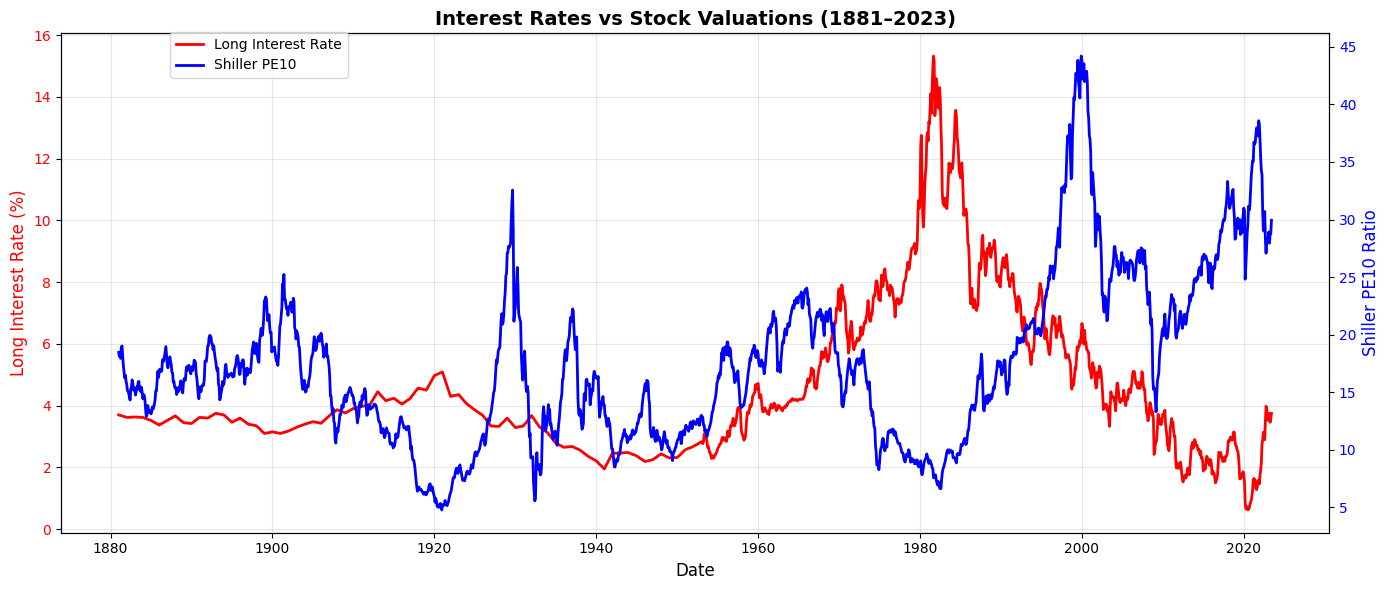

In [13]:
import matplotlib.pyplot as plt


fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Interest Rates on left axis
ax1.plot(df_final_cleaned['Date'], df_final_cleaned['Long Interest Rate'], color='red', label='Long Interest Rate', linewidth=2)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Long Interest Rate (%)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, alpha=0.3)

# Plot PE10 on right axis
ax2 = ax1.twinx()
ax2.plot(df_final_cleaned['Date'], df_final_cleaned['Shiller_PE_Ratio'], color='blue', label='Shiller PE10', linewidth=2)
ax2.set_ylabel('Shiller PE10 Ratio', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')


plt.title('Interest Rates vs Stock Valuations (1881–2023)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

In [14]:
from scipy import stats
import numpy as np

# HYPOTHESIS TEST 1: Correlation Test

print("="*60)
print("HYPOTHESIS TEST 1: Pearson Correlation Test")
print("="*60)

# Calculate correlation and p-value
correlation, p_value = stats.pearsonr(
    df_final_cleaned['Long Interest Rate'],
    df_final_cleaned['Shiller_PE_Ratio']
)

print(f"\nResearch Question: Do higher interest rates relate to lower PE ratios?")
print(f"\nNull Hypothesis (H0): There is NO correlation between interest rates and PE ratios")
print(f"Alternative Hypothesis (H1): There IS a correlation between interest rates and PE ratios")
print(f"\nPearson Correlation Coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance Level (alpha): 0.05")

if p_value < 0.05:
    print(f"\n✓ STATISTICALLY SIGNIFICANT (p < 0.05)")
    print(f"We REJECT the null hypothesis.")
    print(f"There IS a statistically significant correlation between interest rates and PE ratios.")
else:
    print(f"\n✗ NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)")
    print(f"We FAIL TO REJECT the null hypothesis.")
    print(f"There is NO statistically significant correlation.")

print(f"\nInterpretation:")
print(f"A correlation of {correlation:.4f} means that when interest rates increase,")
print(f"PE ratios tend to DECREASE slightly (but the relationship is weak).")

HYPOTHESIS TEST 1: Pearson Correlation Test

Research Question: Do higher interest rates relate to lower PE ratios?

Null Hypothesis (H0): There is NO correlation between interest rates and PE ratios
Alternative Hypothesis (H1): There IS a correlation between interest rates and PE ratios

Pearson Correlation Coefficient: -0.2140
P-value: 0.000000
Significance Level (alpha): 0.05

✓ STATISTICALLY SIGNIFICANT (p < 0.05)
We REJECT the null hypothesis.
There IS a statistically significant correlation between interest rates and PE ratios.

Interpretation:
A correlation of -0.2140 means that when interest rates increase,
PE ratios tend to DECREASE slightly (but the relationship is weak).


In [15]:
# HYPOTHESIS TEST 2: T-Test (High vs Low Interest Rates)

print("\n" + "="*60)
print("HYPOTHESIS TEST 2: Independent Samples T-Test")
print("="*60)


median_interest_rate = df_final_cleaned['Long Interest Rate'].median()

high_interest = df_final_cleaned[df_final_cleaned['Long Interest Rate'] >= median_interest_rate]
low_interest = df_final_cleaned[df_final_cleaned['Long Interest Rate'] < median_interest_rate]


pe_high_interest = high_interest['Shiller_PE_Ratio']
pe_low_interest = low_interest['Shiller_PE_Ratio']


t_statistic, p_value_ttest = stats.ttest_ind(pe_high_interest, pe_low_interest)

print(f"\nResearch Question: Do PE ratios differ between high and low interest rate periods?")
print(f"\nNull Hypothesis (H0): Mean PE ratio is the SAME in high and low interest rate periods")
print(f"Alternative Hypothesis (H1): Mean PE ratio is DIFFERENT in high and low interest rate periods")
print(f"\nMedian Interest Rate (split point): {median_interest_rate:.2f}%")
print(f"\nHIGH Interest Rate Periods (≥ {median_interest_rate:.2f}%):")
print(f"  - Number of months: {len(pe_high_interest)}")
print(f"  - Mean PE ratio: {pe_high_interest.mean():.2f}")
print(f"  - Std Dev: {pe_high_interest.std():.2f}")

print(f"\nLOW Interest Rate Periods (< {median_interest_rate:.2f}%):")
print(f"  - Number of months: {len(pe_low_interest)}")
print(f"  - Mean PE ratio: {pe_low_interest.mean():.2f}")
print(f"  - Std Dev: {pe_low_interest.std():.2f}")

print(f"\nT-Test Results:")
print(f"  - T-statistic: {t_statistic:.4f}")
print(f"  - P-value: {p_value_ttest:.6f}")
print(f"  - Significance Level (alpha): 0.05")

if p_value_ttest < 0.05:
    print(f"\n✓ STATISTICALLY SIGNIFICANT (p < 0.05)")
    print(f"We REJECT the null hypothesis.")
    print(f"PE ratios ARE significantly different between high and low interest rate periods.")

    if pe_high_interest.mean() > pe_low_interest.mean():
        print(f"\nKey Finding: PE ratios are HIGHER during HIGH interest rate periods")
        print(f"Difference: {pe_high_interest.mean() - pe_low_interest.mean():.2f} points")
    else:
        print(f"\nKey Finding: PE ratios are LOWER during HIGH interest rate periods")
        print(f"Difference: {pe_low_interest.mean() - pe_high_interest.mean():.2f} points")
else:
    print(f"\n✗ NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)")
    print(f"We FAIL TO REJECT the null hypothesis.")
    print(f"There is NO significant difference in PE ratios between the two periods.")

print(f"\nInterpretation:")
print(f"This test directly compares stock valuations during expensive and cheap borrowing periods.")


HYPOTHESIS TEST 2: Independent Samples T-Test

Research Question: Do PE ratios differ between high and low interest rate periods?

Null Hypothesis (H0): Mean PE ratio is the SAME in high and low interest rate periods
Alternative Hypothesis (H1): Mean PE ratio is DIFFERENT in high and low interest rate periods

Median Interest Rate (split point): 3.70%

HIGH Interest Rate Periods (≥ 3.70%):
  - Number of months: 855
  - Mean PE ratio: 16.92
  - Std Dev: 8.10

LOW Interest Rate Periods (< 3.70%):
  - Number of months: 855
  - Mean PE ratio: 17.84
  - Std Dev: 6.09

T-Test Results:
  - T-statistic: -2.6722
  - P-value: 0.007608
  - Significance Level (alpha): 0.05

✓ STATISTICALLY SIGNIFICANT (p < 0.05)
We REJECT the null hypothesis.
PE ratios ARE significantly different between high and low interest rate periods.

Key Finding: PE ratios are LOWER during HIGH interest rate periods
Difference: 0.93 points

Interpretation:
This test directly compares stock valuations during expensive and c

/tmp/ipykernel_1234/1601717403.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([pe_low_interest, pe_high_interest],


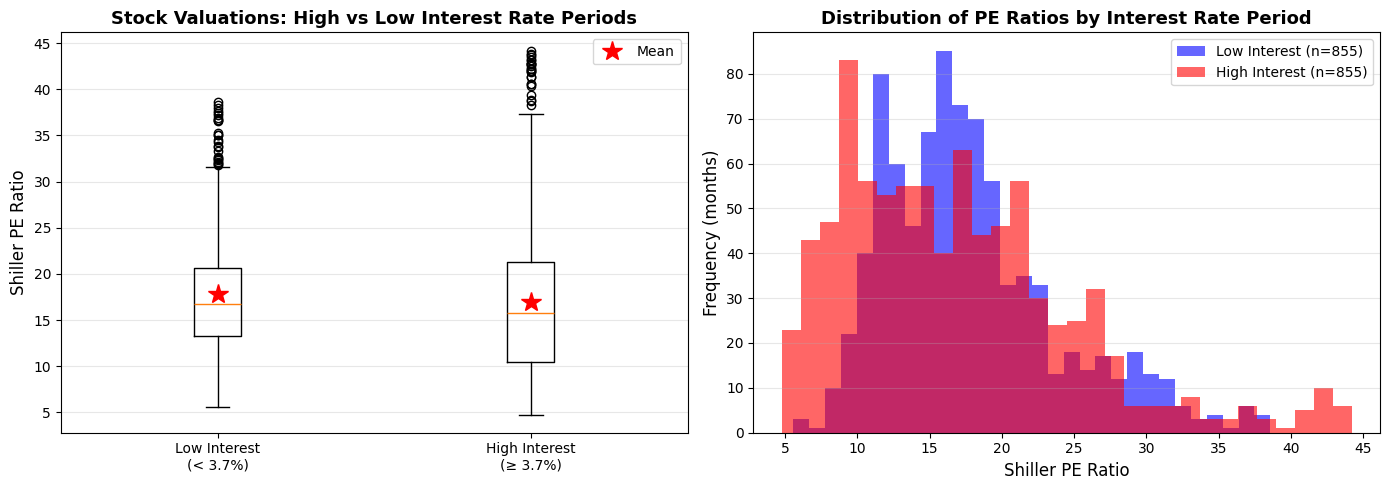


✓ Visualization created showing the difference between groups!


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].boxplot([pe_low_interest, pe_high_interest],
                labels=[f'Low Interest\n(< {median_interest_rate:.1f}%)',
                       f'High Interest\n(≥ {median_interest_rate:.1f}%)'])
axes[0].set_ylabel('Shiller PE Ratio', fontsize=12)
axes[0].set_title('Stock Valuations: High vs Low Interest Rate Periods', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)


means = [pe_low_interest.mean(), pe_high_interest.mean()]
axes[0].plot([1, 2], means, 'r*', markersize=15, label='Mean')
axes[0].legend()


axes[1].hist(pe_low_interest, bins=30, alpha=0.6, label=f'Low Interest (n={len(pe_low_interest)})', color='blue')
axes[1].hist(pe_high_interest, bins=30, alpha=0.6, label=f'High Interest (n={len(pe_high_interest)})', color='red')
axes[1].set_xlabel('Shiller PE Ratio', fontsize=12)
axes[1].set_ylabel('Frequency (months)', fontsize=12)
axes[1].set_title('Distribution of PE Ratios by Interest Rate Period', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization created showing the difference between groups!")

In [17]:
#Summary Table
summary_stats = pd.DataFrame({
    'Metric': ['Count', 'Mean PE Ratio', 'Median PE Ratio', 'Std Dev', 'Min', 'Max'],
    'Low Interest Rate': [
        len(pe_low_interest),
        f"{pe_low_interest.mean():.2f}",
        f"{pe_low_interest.median():.2f}",
        f"{pe_low_interest.std():.2f}",
        f"{pe_low_interest.min():.2f}",
        f"{pe_low_interest.max():.2f}"
    ],
    'High Interest Rate': [
        len(pe_high_interest),
        f"{pe_high_interest.mean():.2f}",
        f"{pe_high_interest.median():.2f}",
        f"{pe_high_interest.std():.2f}",
        f"{pe_high_interest.min():.2f}",
        f"{pe_high_interest.max():.2f}"
    ]
})

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(summary_stats.to_string(index=False))


SUMMARY STATISTICS
         Metric Low Interest Rate High Interest Rate
          Count               855                855
  Mean PE Ratio             17.84              16.92
Median PE Ratio             16.71              15.74
        Std Dev              6.09               8.10
            Min              5.57               4.78
            Max             38.58              44.20


### Bar Chart: Mean Shiller PE Ratio in High vs. Low Interest Rate Periods

This bar chart provides a clear visual comparison of the average Shiller PE Ratio during periods of high and low interest rates, reinforcing the findings from the independent samples t-test.

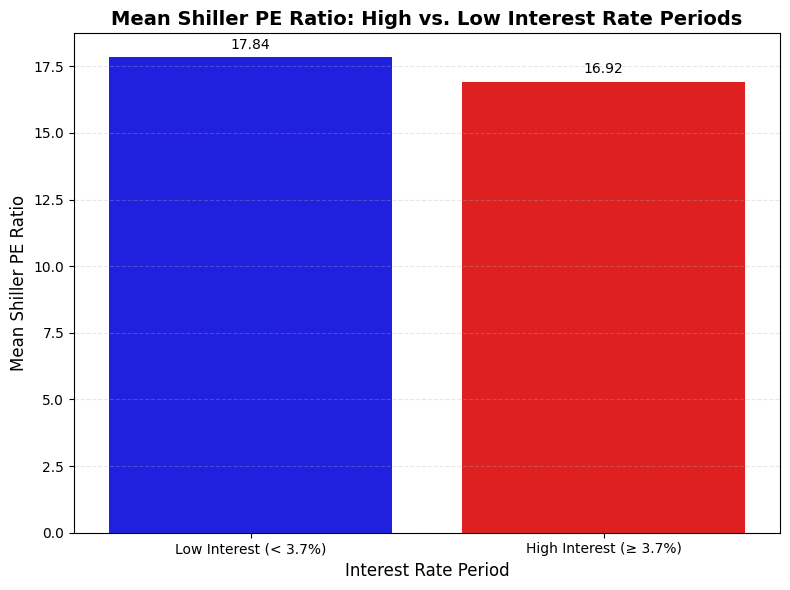

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate means for plotting
mean_pe_low = pe_low_interest.mean()
mean_pe_high = pe_high_interest.mean()


bar_data = pd.DataFrame({
    'Interest Rate Period': [f'Low Interest (< {median_interest_rate:.1f}%)', f'High Interest (≥ {median_interest_rate:.1f}%)'],
    'Mean Shiller PE Ratio': [mean_pe_low, mean_pe_high]
})

plt.figure(figsize=(8, 6))
sns.barplot(
    x='Interest Rate Period',
    y='Mean Shiller PE Ratio',
    data=bar_data,
    hue='Interest Rate Period',
    palette={'Low Interest (< 3.7%)': 'blue', 'High Interest (≥ 3.7%)': 'red'},
    legend=False
)

plt.title('Mean Shiller PE Ratio: High vs. Low Interest Rate Periods', fontsize=14, fontweight='bold')
plt.xlabel('Interest Rate Period', fontsize=12)
plt.ylabel('Mean Shiller PE Ratio', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')


for index, row in bar_data.iterrows():
    plt.text(index, row['Mean Shiller PE Ratio'] + 0.2, f'{row["Mean Shiller PE Ratio"]:.2f}',
             color='black', ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()